<a href="https://colab.research.google.com/github/alexander-toschev/cv-course/blob/main/Tasks/Task2_Orthogonalization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# @title 1) Student Info & Config
# All code comments are in English.

# === ОБЯЗАТЕЛЬНО ЗАПОЛНИТЬ ===
full_name = "Doe John"     # например: "Тощев Александр"
student_group = "11-111"      # например: "208"
assignment_id = "Task2_Orthogonalization"
assert full_name != "Фамилия Имя", "Заполните full_name"
assert student_group != "Группа", "Заполните student_group"
print("✔ Student Info OK")

# Typical human accuracy (benchmark) for MNIST may be ~97-99%.
HUMAN_ACCURACY = 98.0  # @param {type:"number"}

print("Student:", full_name)
print("Human reference accuracy (%):", HUMAN_ACCURACY)

from datetime import datetime, timezone, timedelta

# Установите окна приёма (пример):

start_at_iso = "2025-11-11T09:00-04:00"  #@param {type:"string"}
due_at_iso   = "2025-11-26T23:59-04:00"  #@param {type:"string"}
start_dt = datetime.fromisoformat(start_at_iso)
due_dt   = datetime.fromisoformat(due_at_iso)
# Для протокола: время сдачи берём текущее (можно заменить на mtime файла)
import os
from datetime import datetime, timezone

# 📅 Add submission date based on file modification time
try:
    nb_path = __file__ if "__file__" in globals() else "Transfer_Learning_Assignment.ipynb"
    mtime = os.path.getmtime(nb_path)
    submission_dt = datetime.fromtimestamp(mtime, tz=timezone.utc)
except Exception:
    submission_dt = datetime.utcnow().replace(tzinfo=timezone.utc)

def penalty_fraction(start_dt, due_dt, submission_dt):
    """Возвращает долю штрафа [0..1].
    0 — без штрафа (<= due_dt). Линейно растёт от due_dt к due_dt + (due_dt - start_dt).
    Не выходит за 1.0.
    """
    if submission_dt <= due_dt:
        return 0.0
    total = (due_dt - start_dt).total_seconds()
    late  = (submission_dt - due_dt).total_seconds()
    if total <= 0:
        return 1.0 if late > 0 else 0.0
    return min(1.0, max(0.0, late / total))

print(f"Окно приёма: {start_dt.isoformat()} — {due_dt.isoformat()} (UTC)")
print(f"Время сдачи: {submission_dt.isoformat()} (UTC)")

# Init raw score holder
raw_score = 0.0
max_points = 10


✔ Student Info OK
Student: Doe John
Human reference accuracy (%): 98.0
Окно приёма: 2025-11-11T09:00:00-04:00 — 2025-11-26T23:59:00-04:00 (UTC)
Время сдачи: 2025-11-11T11:44:40.324216+00:00 (UTC)


/tmp/ipython-input-3757342519.py:36: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  submission_dt = datetime.utcnow().replace(tzinfo=timezone.utc)


# 🧠 Практика: Ортогонализация в машинном обучении
Выполни задания ниже, чтобы разобраться, как работает ортогонализация и регуляризация в ML.

## Задание 1: Реализуй функцию `my_gram_schmidt`
Реализуй свою версию функции `my_gram_schmidt`, которая принимает массив `V` и возвращает ортонормированный набор векторов.
```python
def my_gram_schmidt(V):
    # Твоя реализация здесь
    return np.array(U)
```
Проверь результат:
```python
U = my_gram_schmidt(np.array([[1, 1], [1, -1]], dtype=float))
print(np.dot(U[0], U[1]))  # должно быть близко к 0
```

In [3]:
import numpy as np

# Здесь твоя реализация
def my_gram_schmidt(V):

    return np.array(U)

U = my_gram_schmidt(np.array([[1, 1], [1, -1]], dtype=float))
print("Скалярное произведение:", np.dot(U[0], U[1]))

NameError: name 'U' is not defined

In [6]:
import unittest

class TestCommon(unittest.TestCase):
    def test_ridge(self):
        V = np.array([[1, 1], [1, -1]], dtype=float)
        U = my_gram_schmidt(V)
        global raw_score
        assert U.shape == (2, 2), "Неверная форма результата. Должно быть (2, 2)"
        raw_score+=2.5
        dot_product = np.dot(U[0], U[1])
        assert abs(dot_product) < 1e-10, f"Векторы не ортогональны: скалярное произведение = {dot_product}"
        print("✅ Функция my_gram_schmidt проходит тест!")
        raw_score+=2.5



unittest.main(argv=['first-arg-is-ignored'], exit=False)

print(f"Итоговый балл: {raw_score}/{max_points}")

E
ERROR: test_ridge (__main__.TestCommon.test_ridge)
----------------------------------------------------------------------
Traceback (most recent call last):
  File "/tmp/ipython-input-1178623641.py", line 6, in test_ridge
    U = my_gram_schmidt(V)
        ^^^^^^^^^^^^^^^^^^
  File "/tmp/ipython-input-1112481091.py", line 6, in my_gram_schmidt
    return np.array(U)
                    ^
NameError: name 'U' is not defined

----------------------------------------------------------------------
Ran 1 test in 0.004s

FAILED (errors=1)


Итоговый балл: 0.0/10


## Задание 2: Визуализируй результат PCA
Используй PCA на датасете iris и визуализируй 2 компоненты.

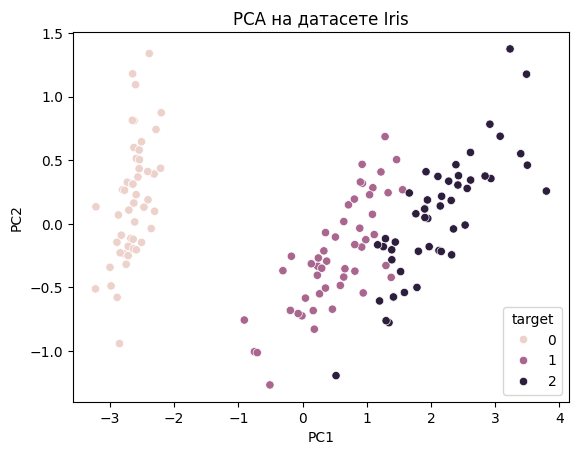

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA

iris = load_iris()
X = iris.data
y = iris.target

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['target'] = y

sns.scatterplot(x='PC1', y='PC2', hue='target', data=df_pca)
plt.title("PCA на датасете Iris")
plt.show()

## Задание 3: Подбери оптимальный alpha в Ridge-регрессии

In [7]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# вернуть минимальную ошибку
def improve_ridge():
    X_train, X_test, y_train, y_test = train_test_split(X[:, :2], y, test_size=0.2, random_state=42)
    alphas = #your code
    errors = #your code

    # your code

    plt.plot(alphas, errors, marker='o')
    plt.xscale('log')
    plt.xlabel('Alpha')
    plt.ylabel('MSE')
    plt.title('Зависимость ошибки от регуляризации')
    plt.grid(True)
    plt.show()
    print(errors)
    return mse


SyntaxError: invalid syntax (ipython-input-688386735.py, line 8)

In [8]:
import unittest

class TestCommon(unittest.TestCase):
    def test_ridge(self):
        mse = improve_ridge()
        print("MSE:", mse)
        global raw_score
        self.assertLessEqual(mse, 0.16, "Error should be less or equal to 16")
        raw_score+=5



unittest.main(argv=['first-arg-is-ignored'], exit=False)

print(f"Итоговый балл: {raw_score}/{max_points}")

E
ERROR: test_ridge (__main__.TestCommon.test_ridge)
----------------------------------------------------------------------
Traceback (most recent call last):
  File "/tmp/ipython-input-4074861521.py", line 5, in test_ridge
    mse = improve_ridge()
          ^^^^^^^^^^^^^
NameError: name 'improve_ridge' is not defined

----------------------------------------------------------------------
Ran 1 test in 0.010s

FAILED (errors=1)


Итоговый балл: 0.0/10


In [9]:
# @title 11) Finalize & Grade (Penalty + JSON)
import json

# применяем штраф
try:
    pf = penalty_fraction(start_dt, due_dt, submission_dt)
except NameError:
    from datetime import timezone
    pf = 0.0
# ✅ Итоговый результат
max_points=10
final_score = max(0.0, raw_score * (1.0 - min(1.0, pf)))

print(f"Сырой балл: {raw_score}/{max_points}")
print(f"Штраф (доля): {pf:.4f}")
print(f"Итоговый балл после штрафа: {final_score:.2f}/{max_points}")

# Последняя строка — JSON, который читает harness
final = {
    "name": full_name,
    "group": student_group,
    "assignment": assignment_id,
    "score": float(final_score)
}



Сырой балл: 0.0/10
Штраф (доля): 0.0000
Итоговый балл после штрафа: 0.00/10
{"name": "Doe John", "group": "11-111", "assignment": "Task2_Orthogonalization", "score": 0.0}


In [ ]:
print(json.dumps(final, ensure_ascii=False))